This section convert texual data into numerical vectors

Machine required numerical input, so text must be converted into numbers (vector)

* One-Hot Encoding
* Bag of Words (BOW)
* Term Frequency - Inverse Document Frequency (TF-IDF)
* N - Gram Language Modelling
* Latent Semantic Analysis (LSA)
* Latent Dirichlet Aloocation (LDA)

In [16]:
from collections import Counter 
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

Word Frequency

In [14]:
# Word Frequency 

text = "NLP is fun and NLP is Powerful. NLP helps machine learning undersatnd human language."
words = word_tokenize(text)
words

['NLP',
 'is',
 'fun',
 'and',
 'NLP',
 'is',
 'Powerful',
 '.',
 'NLP',
 'helps',
 'machine',
 'learning',
 'undersatnd',
 'human',
 'language',
 '.']

In [17]:
stopwords = set(stopwords.words('english'))
filtered = [i for i in words if i.isalpha() and i.lower() not in stopwords]
filtered

['NLP',
 'fun',
 'NLP',
 'Powerful',
 'NLP',
 'helps',
 'machine',
 'learning',
 'undersatnd',
 'human',
 'language']

In [19]:
freq = Counter(filtered)
freq

Counter({'NLP': 3,
         'fun': 1,
         'Powerful': 1,
         'helps': 1,
         'machine': 1,
         'learning': 1,
         'undersatnd': 1,
         'human': 1,
         'language': 1})

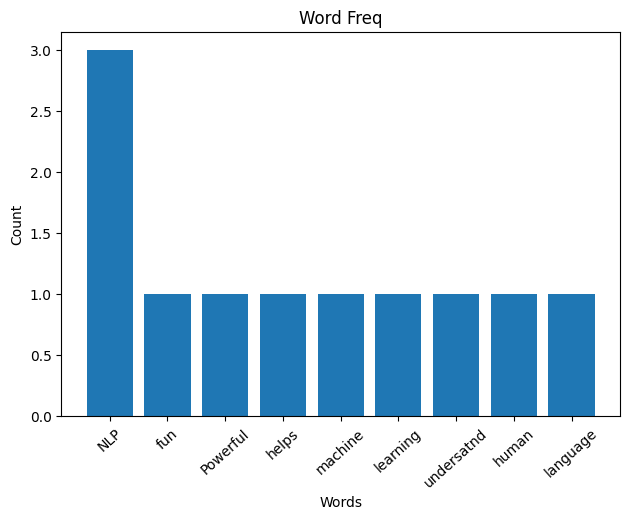

In [25]:
import matplotlib.pyplot as plt
plt.bar(freq.keys(), freq.values())
plt.title('Word Freq')
plt.xlabel("Words")
plt.ylabel('Count')
plt.tight_layout()

#plt.rotate()
plt.xticks(rotation = 42)
plt.show()

TFIDF : Term Frequecny and Inverse Document Frequency

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [27]:
docs = ["I love NLP and Text Mining",
        "Nlp is fun. Text Preocessing is Powerful",
        "I love Python for data and NLP"
        ]

In [28]:
tfid = TfidfVectorizer()

In [29]:
x = tfid.fit_transform(docs)
x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 17 stored elements and shape (3, 12)>

In [31]:
import pandas as pd
df = pd.DataFrame(x.toarray(), columns=tfid.get_feature_names_out())
df

,and,data,for,fun,is,love,mining,nlp,powerful,preocessing,python,text
0,0.433067,0.00000,0.00000,0.000000,0.000000,0.433067,0.569431,0.336315,0.000000,0.000000,0.00000,0.433067
1,0.000000,0.00000,0.00000,0.355173,0.710345,0.000000,0.000000,0.209771,0.355173,0.355173,0.00000,0.270118
2,0.358291,0.47111,0.47111,0.000000,0.000000,0.358291,0.000000,0.278245,0.000000,0.000000,0.47111,0.000000


In [32]:
tfid.get_feature_names_out()

array(['and', 'data', 'for', 'fun', 'is', 'love', 'mining', 'nlp',
       'powerful', 'preocessing', 'python', 'text'], dtype=object)

N grams : 

* N grams : i is continous sequences of words or symbols or tokens in a document. They can be defines as the neighbouring sequence of items in a document.
    - it mainly tries to form the probability between the words to recommend for the next that how many times it has been repeated

* Types of N Grams:
1. Unigram: n = 1 
2. Bigrams: n = 2
3. Trigrams: n = 3 

In [ ]:
word = "hi i am Rahul i am Ai tech i am  willing to explore the hub of AI with different techniques i am rahul"

In [ ]:
from nltk.tokenize import word_tokenize

In [ ]:
w1 = word_tokenize(word)
w1

['hi',
 'i',
 'am',
 'Rahul',
 'i',
 'am',
 'Ai',
 'tech',
 'i',
 'am',
 'willing',
 'to',
 'explore',
 'the',
 'hub',
 'of',
 'AI',
 'with',
 'different',
 'techniques',
 'i',
 'am',
 'rahul']

In [ ]:
from nltk.collocations import BigramCollocationFinder, TrigramCollocationFinder, ngrams

In [ ]:
b = BigramCollocationFinder.from_words(w1)

In [ ]:
b.ngram_fd.keys()

dict_keys([('hi', 'i'), ('i', 'am'), ('am', 'Rahul'), ('Rahul', 'i'), ('am', 'Ai'), ('Ai', 'tech'), ('tech', 'i'), ('am', 'willing'), ('willing', 'to'), ('to', 'explore'), ('explore', 'the'), ('the', 'hub'), ('hub', 'of'), ('of', 'AI'), ('AI', 'with'), ('with', 'different'), ('different', 'techniques'), ('techniques', 'i'), ('am', 'rahul')])

In [ ]:
t = TrigramCollocationFinder.from_words(w1)

In [ ]:
t.ngram_fd

FreqDist({('hi', 'i', 'am'): 1, ('i', 'am', 'Rahul'): 1, ('am', 'Rahul', 'i'): 1, ('Rahul', 'i', 'am'): 1, ('i', 'am', 'Ai'): 1, ('am', 'Ai', 'tech'): 1, ('Ai', 'tech', 'i'): 1, ('tech', 'i', 'am'): 1, ('i', 'am', 'willing'): 1, ('am', 'willing', 'to'): 1, ...})

Counter Vectorize: 

* Counter Vectorize : count how many times each word appear

In [ ]:
import pandas as pd

In [ ]:
l = ["my name is Rahul", "Like to explore AI Tech world"]

In [ ]:
df = pd.DataFrame({"name": l})
df

,name
0,my name is Rahul
1,Like to explore AI Tech world


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
cv = CountVectorizer()

In [ ]:
new_data = cv.fit_transform(df["name"]).toarray()
new_data

array([[0, 0, 1, 0, 1, 1, 1, 0, 0, 0],
       [1, 1, 0, 1, 0, 0, 0, 1, 1, 1]])

In [ ]:
cv.vocabulary_

{'my': 4,
 'name': 5,
 'is': 2,
 'rahul': 6,
 'like': 3,
 'to': 8,
 'explore': 1,
 'ai': 0,
 'tech': 7,
 'world': 9}

Word Cloud Representation

In [34]:
pip install wordcloud


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [36]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [33]:
text = " I Love NLP. NLP is fun and powerful. I love learning NLP with python"

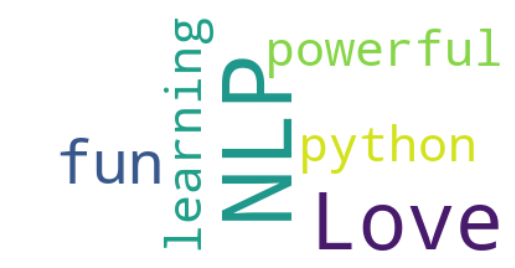

In [38]:
wc = WordCloud(width=400, height=200, background_color='white').generate(text)
plt.imshow(wc, interpolation="bilinear")
plt.axis('off')
plt.show()

Cosine Similiarity: It measures how similar two texts are based on their vectors (like TF-IDF)
Value ranges:
1 → exactly same
0 → completely different

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

documents = [
    "I love data science",
    "I love machine learning",
    "Football is a great sport"
]

# Step 1: TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)

# Step 2: Cosine Similarity
similarity = cosine_similarity(tfidf_matrix)

print(similarity)

[[1.       0.224325 0.      ]
 [0.224325 1.       0.      ]
 [0.       0.       1.      ]]


In [41]:
import pandas as pd
df = pd.DataFrame(similarity, columns=documents, index=documents)
df

,I love data science,I love machine learning,Football is a great sport
I love data science,1.000000,0.224325,0.0
I love machine learning,0.224325,1.000000,0.0
Football is a great sport,0.000000,0.000000,1.0


sentimental analysis
* lexicons Dictionary
* Textblob
* vader analysis (mostly used)

In [43]:
texts = [
    "I love this product",
    "This is the worst experience ever",
    "The movie is not bad",
    "Absolutely amazing service!!! 😍"
]

In [ ]:
# lexicon mostly works on dictionary based
positive = ["love", "amazing", "good"]
negative = ["bad", "worst", "hate"]

print("Lexicon:\n")

for t in texts:
    score = 0
    for word in t.lower().split():
        if word in positive:
            score += 1
        if word in negative:
            score -= 1
    
    print(t, "->", "Positive" if score>0 else "Negative" if score<0 else "Neutral")

Lexicon:

I love this product -> Positive
This is the worst experience ever -> Negative
The movie is not bad -> Negative
Absolutely amazing service!!! 😍 -> Positive


In [45]:
pip install textblob

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.0/625.0 kB 3.2 MB/s  0:00:0036m-:--:--

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# textblob
from textblob import TextBlob

print("\nTextBlob:\n")

for t in texts:
    p = TextBlob(t).sentiment.polarity
    print(t, "->", "Positive" if p>0 else "Negative" if p<0 else "Neutral")


TextBlob:

I love this product -> Positive
This is the worst experience ever -> Negative
The movie is not bad -> Positive
Absolutely amazing service!!! 😍 -> Positive


In [48]:
import nltk

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/rahulg/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [50]:
# vader 
from nltk.sentiment import SentimentIntensityAnalyzer


analys = SentimentIntensityAnalyzer()

print("\nVADER:\n")

for t in texts:
    c = analys.polarity_scores(t)['compound']
    print(t, "->", "Positive" if c>0 else "Negative" if c<0 else "Neutral")


VADER:

I love this product -> Positive
This is the worst experience ever -> Negative
The movie is not bad -> Positive
Absolutely amazing service!!! 😍 -> Positive
